In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [14]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [15]:
import random
random.seed(42)
random.shuffle(words)
words

['nyree',
 'edie',
 'coalson',
 'shaindy',
 'bryer',
 'kycie',
 'miani',
 'aveah',
 'maliha',
 'patience',
 'corra',
 'ayomikun',
 'elham',
 'noelly',
 'yosiyah',
 'micheala',
 'aaliyah',
 'jaceson',
 'dailyn',
 'zhaviyah',
 'nicolai',
 'lawson',
 'yura',
 'macayla',
 'mishael',
 'kaisyn',
 'abass',
 'yunay',
 'ava',
 'nairobi',
 'ayma',
 'maleyah',
 'cadin',
 'silvanna',
 'brezlynn',
 'davida',
 'story',
 'analiyah',
 'chavi',
 'loyd',
 'mena',
 'maryelizabeth',
 'mckay',
 'finlay',
 'wendi',
 'romulus',
 'asriel',
 'kris',
 'jimmie',
 'afnan',
 'celine',
 'macsen',
 'amra',
 'berend',
 'hassen',
 'saud',
 'miesha',
 'avaley',
 'kashus',
 'anais',
 'jamilette',
 'jordan',
 'lamees',
 'breelyn',
 'oshay',
 'koa',
 'davien',
 'nasya',
 'copeland',
 'zamyah',
 'rakeem',
 'uday',
 'braylan',
 'rondale',
 'breyer',
 'chiziterem',
 'emiya',
 'kyliegh',
 'crixus',
 'deandra',
 'evelio',
 'portlyn',
 'maleko',
 'kenza',
 'jonel',
 'lania',
 'euna',
 'lamis',
 'shaniah',
 'blakelyn',
 'kashi',

In [67]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
block_size = 8 # context length

def build_dataset(words):
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182424, 8]) torch.Size([182424])
torch.Size([22836, 8]) torch.Size([22836])
torch.Size([22886, 8]) torch.Size([22886])


In [66]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> n
.......n --> y
......ny --> r
.....nyr --> e
....nyre --> e
...nyree --> .
........ --> e
.......e --> d
......ed --> i
.....edi --> e
....edie --> .
........ --> c
.......c --> o
......co --> a
.....coa --> l
....coal --> s
...coals --> o
..coalso --> n
.coalson --> .
........ --> s


In [126]:
# Already built in "build_makemore_yay_RNN.ipynb"

# ----------------------------------------------------------------------------------
class Linear:
    def __init__(self, fan_in, fan_out, bias=True, device=None):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in **0.5
        self.bias = torch.zeros(fan_out) if bias else None
        #self.device = torch.device('gpu' if  torch.cuda.is_available else 'cpu')

    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
# ----------------------------------------------------------------------------------
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

# ---------------------------------------------------------------------------------
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
# ---------------------------------------------------------------------------------
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
# ---------------------------------------------------------------------------------
class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1) # squeeze only the T//n dimension
        self.out = x
        return self.out
    
    def parameters(self):
        return []
# ---------------------------------------------------------------------------------
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get params of all layers and stretch them out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [127]:
torch.manual_seed(42);

In [132]:
n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # nr of params in total
for p in parameters:
    p.requires_grad = True

76579


In [129]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # lets look at a batch of only 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  6],
        [ 0,  0,  0,  0,  0,  0, 25,  1],
        [ 0,  0,  0, 19,  9, 13, 15, 14]])

In [130]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [131]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [72]:
torch.randn(4, 5, 6, 200, 200).nelement()

4800000

In [78]:
e = torch.randn(4, 8, 10) # goal: want to be (4, 4, 20) where consecutive 10-d vectors get catted
#e.view(4, -1).shape
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2) # gives us the even and the odd characters
explicit.shape 

torch.Size([4, 4, 20])

In [77]:
(e.view(4, 4, 20) == torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)).all()

tensor(True)

In [104]:
max_steps = 1000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.5 #0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    #break

      0/   1000: 3.3135


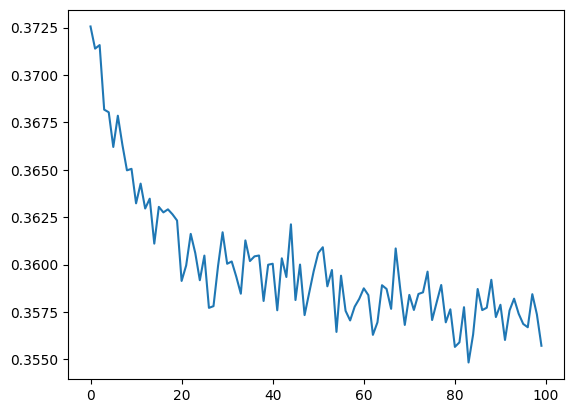

In [36]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [29]:
torch.arange(10).view(-1, 5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [ ]:
# put layers in eval mode
for layer in model.layers:
    layer.training = False

In [58]:
@torch.no_grad() # This disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
# split_loss('test')

train 2.424262046813965
val 2.4378249645233154


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 8)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
        
    print(''.join(itos[i] for i in out)) # decode and print the generated word

C:\Users\User\AppData\Local\Temp\ipykernel_1128\1756798868.py:35: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  xvar = x.var(0, keepdim=True, unbiased=True) # batch variance


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

In [133]:
for x,y in zip(Xtr[3:11], Ytr[3:11]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

.....nyr --> e
....nyre --> e
...nyree --> .
........ --> e
.......e --> d
......ed --> i
.....edi --> e
....edie --> .


In [137]:
Xtr[3].shape, Xtr[[3]].shape

(torch.Size([8]), torch.Size([1, 8]))

In [134]:
# forward a single eg:
logits = model(Xtr[[7]])
logits.shape

C:\Users\User\AppData\Local\Temp\ipykernel_1128\1555834072.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True, unbiased=True) # batch variance


torch.Size([1, 27])

In [135]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
    logits[i] = model(Xtr[[3+i]])
logits.shape

C:\Users\User\AppData\Local\Temp\ipykernel_1128\1555834072.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True, unbiased=True) # batch variance


torch.Size([8, 27])

In [ ]:
# convolution is a "for loop"
# allows to forward Linear layers efficiently over space